# LightGBM — Network Intrusion Detection

Huấn luyện và đánh giá mô hình **LightGBM** trên tập dữ liệu CICIDS2017.

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

# Thêm thư mục gốc dự án vào sys.path
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_splits,
    evaluate_model,
    plot_confusion_matrix,
    compare_models,
)

In [2]:
# --- STEP 1: Load dữ liệu đã chia sẵn ---
print("=" * 70)
print("STEP 1: Loading pre-split data")
print("=" * 70)

X_train, X_test, y_train, y_test = load_splits()

print(f"Feature columns: {X_train.shape[1]}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading pre-split data
Loaded splits from disk.
Feature columns: 52
Train size: 2,016,609  |  Test size: 504,153
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# --- STEP 2: Train LightGBM ---
print("\n" + "=" * 70)
print("STEP 2: Training LightGBM (n_estimators=200)")
print("=" * 70)

t0 = time.time()

lgb_model = lgb.LGBMClassifier(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"Training completed in {train_time:.2f} seconds")
print(f"Number of features: {lgb_model.n_features_in_}")
print(f"Number of classes: {len(lgb_model.classes_)}")


STEP 2: Training LightGBM (n_estimators=200)
Training completed in 513.87 seconds
Number of features: 52
Number of classes: 10


In [4]:
# --- STEP 3: Evaluate ---
print("\n" + "=" * 70)
print("STEP 3: Model Evaluation")
print("=" * 70)

y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)

lgb_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="LightGBM (n_estimators=200)",
    y_pred_proba=y_pred_proba,
    labels=lgb_model.classes_.tolist(),
)


STEP 3: Model Evaluation

  LightGBM (n_estimators=200) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.83      0.82      0.83       390
               Brute Force       1.00      1.00      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      1.00      1.00         2
                  PortScan       0.99      1.00      0.99     18139
  Web Attack � Brute Force       0.75      0.80      0.77       294
Web Attack � Sql Injection       0.50      0.25      0.33         4
          Web Attack � XSS       0.46      0.37      0.41       130

                  accuracy                           1.00    504153
                 macro avg       0.85      0.82      0.83    504153
              weighted avg       1.0


STEP 4: Confusion Matrix


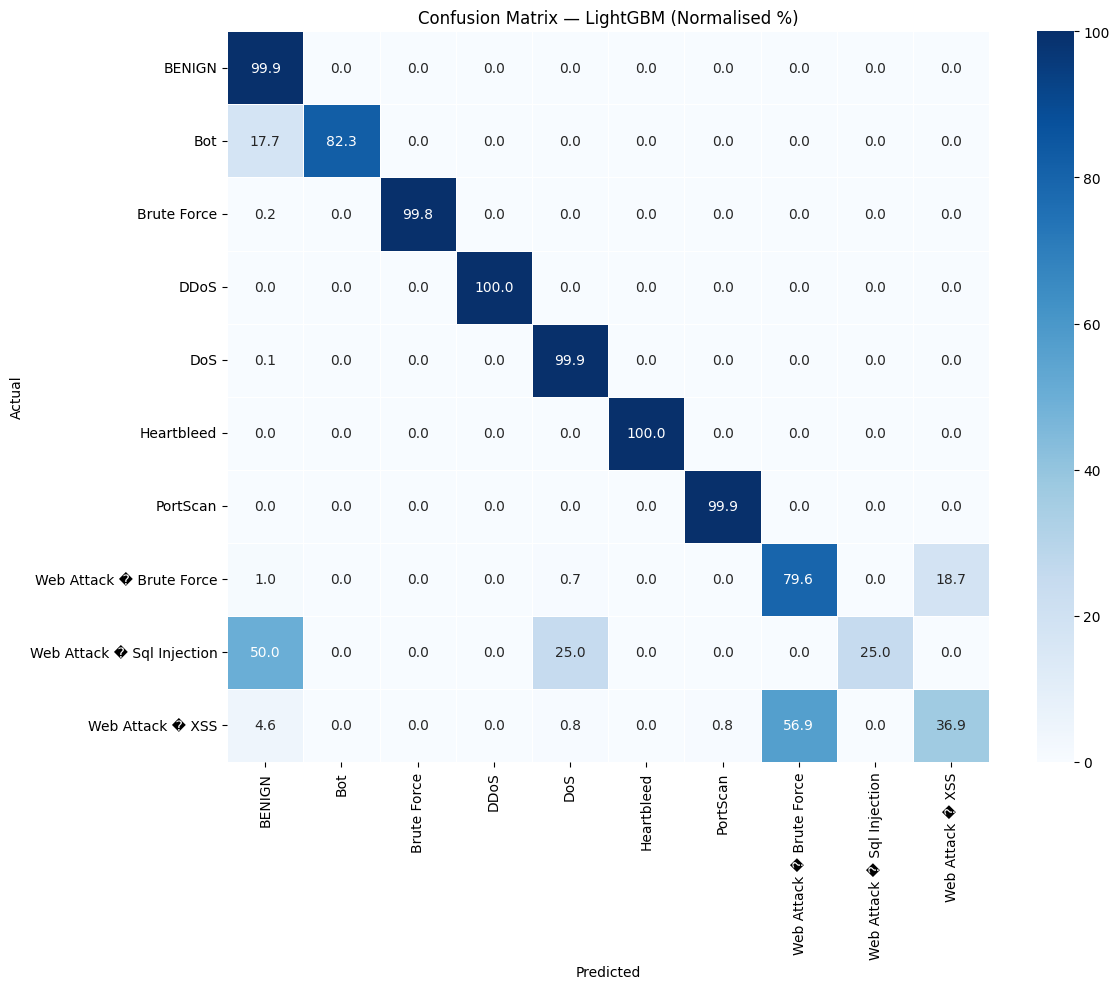

In [5]:
# --- STEP 4: Confusion Matrix ---
print("\n" + "=" * 70)
print("STEP 4: Confusion Matrix")
print("=" * 70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=lgb_model.classes_.tolist(),
    model_name="LightGBM",
    normalize=True,
    figsize=(12, 10),
)


STEP 5: Feature Importance (Top 20)
                Feature  Importance
           Flow IAT Min       10076
            Fwd IAT Min        5649
       Destination Port        5529
 Init_Win_bytes_forward        4669
            Fwd IAT Std        3599
Init_Win_bytes_backward        2817
          Fwd IAT Total        2502
          Flow Duration        2418
            Bwd IAT Std        2284
          Fwd Packets/s        2265
           Flow IAT Max        2241
          Bwd Packets/s        2160
          Flow IAT Mean        2151
            Fwd IAT Max        2131
           Fwd IAT Mean        1858
           Flow Bytes/s        1812
         Flow Packets/s        1605
            Bwd IAT Min        1234
           Flow IAT Std        1117
   min_seg_size_forward         971


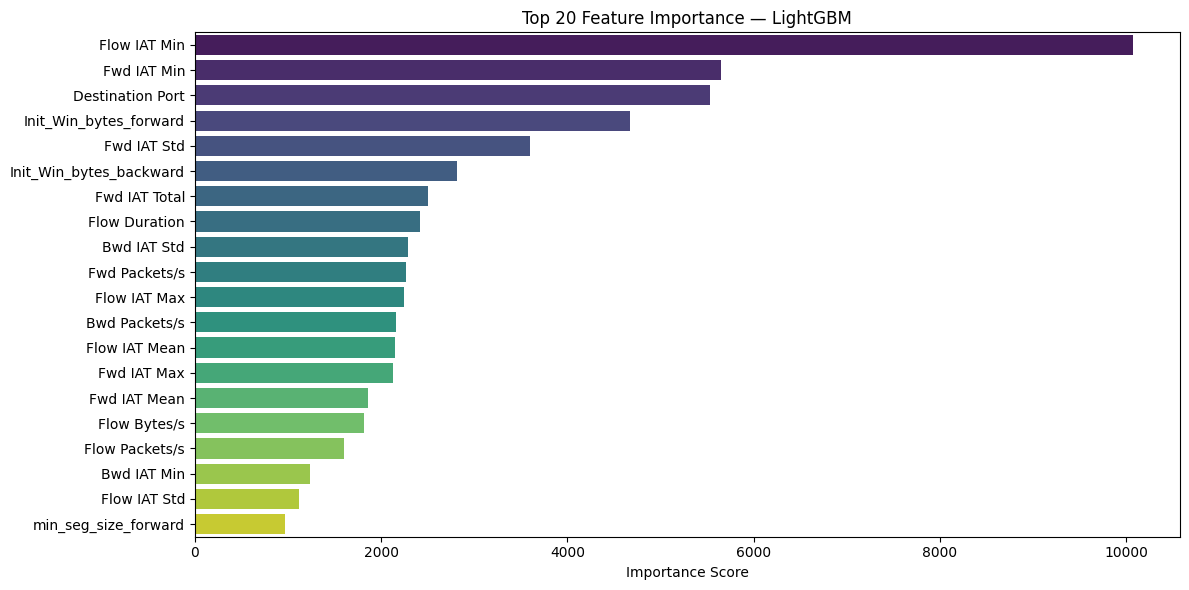

In [6]:
# --- STEP 5: Feature Importance ---
print("\n" + "=" * 70)
print("STEP 5: Feature Importance (Top 20)")
print("=" * 70)

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x="Importance", y="Feature",
    hue="Feature", legend=False,
    palette="viridis",
)
plt.title("Top 20 Feature Importance — LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [7]:
# --- STEP 6: Summary ---
print("\n" + "=" * 70)
print("STEP 6: Summary")
print("=" * 70)

comparison_df = compare_models([lgb_results])
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

print(f"\nTraining time  : {train_time:.2f}s")
print(f"Test set size  : {len(y_test):,}")
print(f"Estimators     : 200")
print(f"Features       : {X_train.shape[1]}")
print(f"Classes        : {len(lgb_model.classes_)}")


STEP 6: Summary

Performance Metrics:
                      Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
LightGBM (n_estimators=200)    0.9989                0.9988              0.853             0.9989          0.8235         0.9989      0.8335       0.9962 0.9962              0.9998           0.9985

Training time  : 513.87s
Test set size  : 504,153
Estimators     : 200
Features       : 52
Classes        : 10
